# Does the warehouse tell the same story as the file Meera's decision rested on?

**Week 2, Monday. Chapter 2 of 6.** Chapter 1 counted the book's first leaves; this chapter
sets every leaf beside the ones last week's note was built on.

> "Before your numbers go in my book, show me they match the ones you gave Meera."
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand wants to know which numbers the sheet is signing for, and Meera Raghavan,
Kalpa Retail's CEO, parked a Rs 12 crore acquisition budget last week on the team's finding
that customers held steady while each ordered less often. If the book tells a different story
and nobody says so, a Rs 12 crore decision stays parked on a number the warehouse does not
support, and the team's next number is doubted before anyone reads it.

**The questions on the way.**
1. How can two sources of different sizes be compared fairly?
2. Does last week's file still give last week's numbers?
3. Which leaves agree once each is read as a change from Q1 to Q2?
4. Did the customer leaf agree?
5. Where did the book's 17 fewer Q2 customers come from?
6. What goes on Anand's sheet about last week's note?

**The metric at stake.** Every leaf of the tree and its change from Q1 (April to June 2026) to
Q2 (July to September 2026): revenue, orders, customers who bought, orders per customer and
revenue per order. Revenue is booked revenue, every status included.

**What chapter 1 found.** The warehouse books 538 orders and Rs 10,00,00,000 in Q1 and 462
orders and Rs 9,84,00,000 in Q2, with 244 and 227 customers who bought, each counted once.
Last week's extract held 186 cleaned orders: 100 and 86 orders, Rs 1,90,00,000 and
Rs 1,87,00,000, and 69 customers in each quarter. Meera accepted "real, modest, fix frequency"
from it.

**A real company with the same question.** Airbnb's data team wrote in April 2021 that when the
chief executive asked which city had the most bookings in the previous week, "Data Science and
Finance would sometimes provide diverging answers using slightly different tables, metric
definitions, and business logic" (The Airbnb Tech Blog, "How Airbnb Achieved Metric Consistency
at Scale", 30 April 2021). Two sources that answer one question differently are settled leaf by
leaf before either reaches a decision maker.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D01_02_same_story_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

Q = blocks("02_same_story")
print(len(Q), "named queries read from", "C2_W02_D01_02_same_story_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

import csv
W1_FILE = kit.data_dir() / "C2_W02_D01_week1_orders_STUDENT.csv"
w1_rows = list(csv.DictReader(W1_FILE.open(encoding="utf-8")))
print(len(w1_rows), "rows read from last week's extract,", W1_FILE.name)

6 named queries read from C2_W02_D01_02_same_story_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu
186 rows read from last week's extract, C2_W02_D01_week1_orders_STUDENT.csv


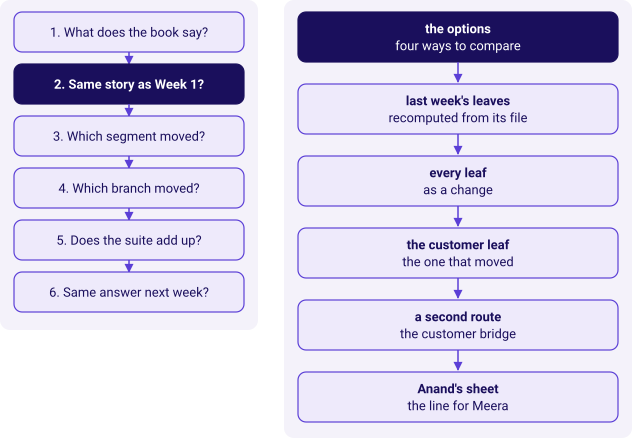

In [2]:
kit.side_by_side(
    kit.ladder(['What does the book say?', 'Same story as Week 1?', 'Which segment moved?', 'Which branch moved?', 'Does the suite add up?', 'Same answer next week?'], lit=1, show=False),
    kit.vflow(['the options\nfour ways to compare', "last week's leaves\nrecomputed from its file", 'every leaf\nas a change', 'the customer leaf\nthe one that moved', 'a second route\nthe customer bridge', "Anand's sheet\nthe line for Meera"], lit=0, show=False),
)

## The options: how can two sources of different sizes be compared fairly?

The extract held 186 orders and the warehouse holds 1,000, so their totals were never going to
match. Four ways a team could compare them:

| Option | What it compares | What it can catch | What it assumes |
|---|---|---|---|
| A. The two totals | Q1 and Q2 revenue in each source | A different fall | That matching totals mean matching leaves |
| B. Every leaf, as a change from Q1 to Q2 | Five leaves in each quarter in each source | Any branch that moved differently | That both sources use the same definitions |
| C. Order by order, on the order id | Each of the extract's orders looked up in the warehouse | A missing or altered order | That the two sources share order ids |
| D. Last week's notebook rerun on an export | Everything Week 1 computed | Anything Week 1's code checks | An export, which the platform lead ruled out |

**Predict before you run.** Option C is the strictest. How many of the extract's 186 order ids
will it find in the warehouse?

- a) All 186, since the warehouse holds the same two quarters.
- b) About 150, since the extract was cleaned.
- c) None at all.
- d) It cannot be known without the ERP.

In [3]:
wh_orders = {r["order_id"] for r in kit.sql(Q["c2_order_ids"])}
wh_customers = {r["customer_id"] for r in kit.sql(Q["c2_customer_ids"])}
shared_orders = len({r["order_id"] for r in w1_rows} & wh_orders)
shared_customers = len({r["customer_id"] for r in w1_rows} & wh_customers)
sizing = [("A. the two totals", "4 numbers", "a different fall only"),
          ("B. every leaf, as a change", "20 numbers", "any branch that moved"),
          ("C. order by order", f"{len(w1_rows)} lookups, {shared_orders} found", "nothing: no shared ids"),
          ("D. rerun on an export", "1,340 rows exported", "ruled out by the platform lead")]
kit.table(["option", "what it touches here", "what it can catch here"], sizing,
          caption="The four ways sized on these two sources")
kit.stats([(str(shared_orders), "order ids shared", f"the extract's {len(w1_rows)} against the book's {len(wh_orders):,}"),
           (str(shared_customers), "customer ids shared", f"the extract's 69 against the book's {len(wh_customers)}")],
          caption="The two sources hold different records of the same two quarters")

option,what it touches here,what it can catch here
A. the two totals,4 numbers,a different fall only
"B. every leaf, as a change",20 numbers,any branch that moved
C. order by order,"186 lookups, 0 found",nothing: no shared ids
D. rerun on an export,"1,340 rows exported",ruled out by the platform lead


**What happened.** The answer is c: none. The extract and the warehouse share no order id and
no customer id, so option C finds nothing and option D would need an export. Option A compares
four numbers and can only catch a different fall.

**The best-fit call.** Option B, every leaf read as a change from Q1 to Q2. A change survives a
difference in size, and five leaves in each source are twenty numbers to set side by side.
**What would change the call:** if the two sources shared order ids, option C would prove or
disprove every order, and it would win.

In [4]:
kit.check("the sources share no order id", shared_orders == 0)
kit.check("the sources share no customer id", shared_customers == 0)

## 1. Does last week's file still give last week's numbers?

Before last week's leaves are compared with anything, they are recomputed from last week's own
file, so both columns of the comparison come from a computation rather than from memory.

**Predict before you run.** How many of the extract's 69 customers bought in both quarters?

- a) All 69.
- b) About half, 35.
- c) None, since each quarter held different customers.
- d) It cannot be counted from one file.

In [5]:
def leaves(rows):
    """Customers, orders and revenue per quarter, plus the customers who bought in both."""
    out = {}
    for q in ("Q1", "Q2"):
        r = [x for x in rows if x["quarter"] == q]
        out[q] = {"customers": len({x["customer_id"] for x in r}), "orders": len(r),
                  "revenue": sum(float(x["amount"]) for x in r)}
    ids = [{x["customer_id"] for x in rows if x["quarter"] == q} for q in ("Q1", "Q2")]
    out["both"] = len(ids[0] & ids[1])
    out["anyone"] = len(ids[0] | ids[1])
    return out

w1 = leaves(w1_rows)
kit.table(["quarter", "orders", "customers", "revenue"],
          [(q, w1[q]["orders"], w1[q]["customers"], kit.rupees(w1[q]["revenue"])) for q in ("Q1", "Q2")],
          caption="Last week's extract, recomputed from its own file")
print(f"Customers who bought in both quarters: {w1['both']} of {w1['anyone']}")

quarter,orders,customers,revenue
Q1,100,69,"Rs 1,90,00,000"
Q2,86,69,"Rs 1,87,00,000"


Customers who bought in both quarters: 69 of 69


In [6]:
kit.check("the file holds last week's 186 orders", len(w1_rows) == 186)
kit.check("it reproduces Rs 1,90,00,000 and Rs 1,87,00,000",
          (w1["Q1"]["revenue"], w1["Q2"]["revenue"]) == (19000000, 18700000))
kit.check("it reproduces 69 customers in each quarter", (w1["Q1"]["customers"], w1["Q2"]["customers"]) == (69, 69))

**What happened.** The answer is a: all 69 of the extract's customers bought in both quarters.
The file reproduces last week's numbers, so the comparison below starts from what Meera was
told, recomputed.

## 2. Which leaves agree once each is read as a change from Q1 to Q2?

The book's own leaves come from one query, and each leaf is read as Q2 over Q1 in both sources.

**Predict before you run.** Revenue fell 1.6 percent in both. How many of the other four leaves
will agree to within a point?

- a) All four.
- b) Two: orders and revenue per order.
- c) One.
- d) None, since the sources share no record.

-- The question: every leaf of the tree for each quarter, from the warehouse.
SELECT quarter,
       count(DISTINCT customer_id) AS customers,
       count(*)                    AS orders,
       sum(amount)                 AS revenue
FROM   orders
GROUP  BY quarter
ORDER  BY quarter;


quarter,customers,orders,revenue
Q1,244,538,"Rs 10,00,00,000"
Q2,227,462,"Rs 9,84,00,000"


leaf,"last week's extract, Q1 to Q2","the warehouse, Q1 to Q2","gap, points"
revenue,-1.6%,-1.6%,+0.0
orders,-14.0%,-14.1%,-0.1
customers,+0.0%,-7.0%,-7.0
orders per customer,-14.0%,-7.7%,+6.3
revenue per order,+14.4%,+14.6%,+0.1


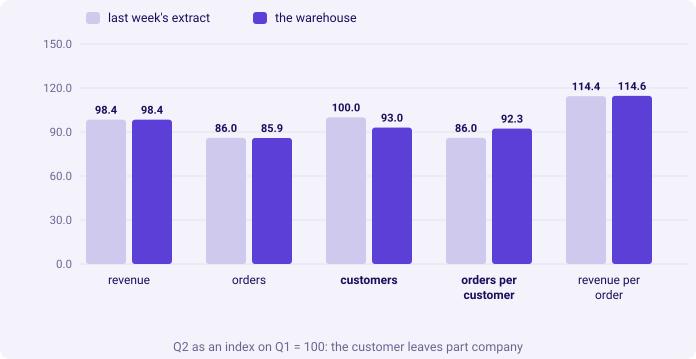

In [7]:
book = {r["quarter"]: {k: num(v) for k, v in r.items()}
        for r in run("c2_leaves", "The book's leaves, one row per quarter", money=("revenue",))}

def branch(d, name):
    q1, q2 = d["Q1"], d["Q2"]
    if name == "orders per customer":
        return q1["orders"] / q1["customers"], q2["orders"] / q2["customers"]
    if name == "revenue per order":
        return q1["revenue"] / q1["orders"], q2["revenue"] / q2["orders"]
    return q1[name], q2[name]

LEAVES = ["revenue", "orders", "customers", "orders per customer", "revenue per order"]
compare = []
for name in LEAVES:
    a, b = branch(w1, name), branch(book, name)
    compare.append((name, pct(*a), pct(*b)))
kit.table(["leaf", "last week's extract, Q1 to Q2", "the warehouse, Q1 to Q2", "gap, points"],
          [(n, f"{a:+.1f}%", f"{b:+.1f}%", f"{round(b - a, 1) + 0.0:+.1f}") for n, a, b in compare],
          caption="Every leaf as a change: two sources of different sizes, compared fairly")
kit.columns([n for n, *_ in compare],
            [("last week's extract", [round(100 + a, 1) for _, a, _ in compare]),
             ("the warehouse", [round(100 + b, 1) for _, _, b in compare])],
            title="Q2 as an index on Q1 = 100: the customer leaves part company",
            fmt=lambda v: f"{v:.1f}", lit=(2, 3))

**What happened.** The answer is b. Revenue (down 1.6 percent in both), orders (down 14.0 and
14.1) and revenue per order (up 14.4 and 14.6) agree to within half a point. Customers and
orders per customer do not: the extract's customers held flat and each ordered 14.0 percent
less often, while the book's customers fell 7.0 percent and each ordered 7.7 percent less
often.

In [8]:
gap = {n: b - a for n, a, b in compare}
kit.check("revenue, orders and revenue per order agree to within a point",
          all(abs(gap[n]) < 1 for n in ("revenue", "orders", "revenue per order")))
kit.check("the customer leaf differs by 7 points", round(gap["customers"]) == -7, f"{gap['customers']:+.1f}")
kit.check("orders per customer differs by about 6 points", 5 < gap["orders per customer"] < 7,
          f"{gap['orders per customer']:+.1f}")

## 3. Did the customer leaf agree?

A hurried analyst stops at the totals: both sources fall 1.6 percent, so "the warehouse
confirms last week", and Anand's sheet carries last week's branch story unchanged.

**Predict before you run.** If the sheet copies the customer leaf from last week, what does it
say customers did from Q1 to Q2?

- a) Fell 7.0 percent.
- b) Held flat, 0.0 percent.
- c) Fell 14.0 percent.
- d) Rose 1.6 percent.

In [9]:
hurried = {"customers": pct(w1["Q1"]["customers"], w1["Q2"]["customers"]),
           "orders per customer": pct(*branch(w1, "orders per customer"))}
honest = {"customers": pct(book["Q1"]["customers"], book["Q2"]["customers"]),
          "orders per customer": pct(*branch(book, "orders per customer"))}
kit.table(["leaf on Anand's sheet", "the hurried sheet, copied from last week", "the book"],
          [(n, f"{hurried[n]:+.1f}%", f"{honest[n]:+.1f}%") for n in hurried],
          caption="The plausible wrong answer beside the book's own leaves")

leaf on Anand's sheet,"the hurried sheet, copied from last week",the book
customers,+0.0%,-7.0%
orders per customer,-14.0%,-7.7%


**The plausible wrong answer.** "Customers held flat, 0.0 percent; each ordered 14.0 percent
less often." It is last week's branch story, carried onto the book because the totals matched.
On Anand's sheet it keeps the Rs 12 crore parked on a customer count the book does not show.

**Why it is wrong.** Two trees can multiply to the same total with different branches. The
extract's revenue ratio is 1.000 for customers times 0.860 for frequency times 1.144 for order
value, and the book's is 0.930 times 0.923 times 1.146; both come to 0.984. A matching total is
one leaf matching. The answer is b.

**The check that exposes it.** Count, in each source, how many customers bought in both
quarters.

-- The question: which customers bought in both quarters? One row per customer.
SELECT customer_id
FROM   orders
GROUP  BY customer_id
HAVING count(DISTINCT quarter) = 2
ORDER  BY customer_id;


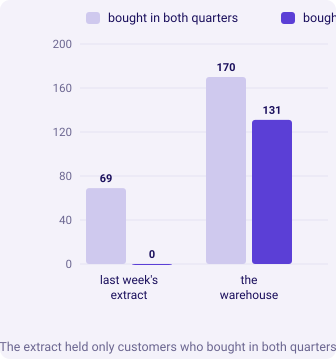

source,customers,orders per customer,revenue per order,product
extract,1.0,0.86,1.144,0.984
book,0.93,0.923,1.146,0.984


In [10]:
both = len(kit.sql(Q["c2_bought_in_both"]))
only_q1 = len(kit.sql(Q["c2_bought_q1_only"]))
only_q2 = len(kit.sql(Q["c2_bought_q2_only"]))
print(Q["c2_bought_in_both"])
anyone = both + only_q1 + only_q2
kit.columns(["last week's extract", "the warehouse"],
            [("bought in both quarters", [w1["both"], both]),
             ("bought in one quarter only", [w1["anyone"] - w1["both"], only_q1 + only_q2])],
            title="The extract held only customers who bought in both quarters")
def branch_ratios(d):
    """Q2 over Q1 for the three branches of the tree, to three places."""
    return tuple(round(b / a, 3) for a, b in (branch(d, "customers"), branch(d, "orders per customer"),
                                              branch(d, "revenue per order")))
ratios = {"extract": branch_ratios(w1), "book": branch_ratios(book)}
kit.table(["source", "customers", "orders per customer", "revenue per order", "product"],
          [(s, *r, f"{r[0] * r[1] * r[2]:.3f}") for s, r in ratios.items()],
          caption="Two trees, one total: different branches multiply to the same 0.984")

In [11]:
kit.check("every customer in the extract bought in both quarters", w1["both"] == w1["anyone"] == 69)
kit.check("170 of the book's 301 customers bought in both quarters", (both, anyone) == (170, 301))
kit.check("both trees multiply to the same revenue ratio",
          abs(ratios["book"][0] * ratios["book"][1] * ratios["book"][2] - 0.984) < 0.001)

**The fix, and what it changed.** The sheet carries the book's own leaves: 244 customers bought
in Q1 and 227 in Q2, 7.0 percent fewer, and each ordered 7.7 percent less often. Every one of
the extract's 69 customers bought in both quarters, so its customer count could not fall; the
book holds 131 customers who bought in only one of them.

## A second route: where did the book's 17 fewer Q2 customers come from?

The first route subtracted two distinct counts, 244 less 227. The second route builds the same
change from each customer's own history: Q1's customers, less the ones who bought in Q1 and not
in Q2, plus the ones who bought in Q2 and not in Q1. It uses three `HAVING` filters on one row
per customer, with no distinct count per quarter anywhere in it.

**Predict before you run.** How many of Q1's 244 customers bought nothing in Q2?

- a) 17, the net fall.
- b) 74.
- c) 57.
- d) 244, since the quarters are separate.

-- The question: which customers bought in Q1 and not in Q2?
SELECT customer_id
FROM   orders
GROUP  BY customer_id
HAVING max(quarter) = 'Q1'
ORDER  BY customer_id;


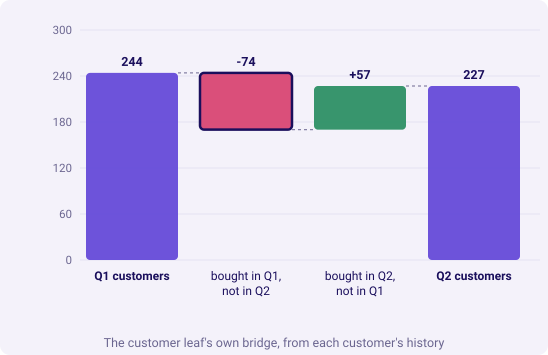

244 - 74 + 57 = 227


In [12]:
print(Q["c2_bought_q1_only"])
kit.bridge(("Q1 customers", book["Q1"]["customers"]),
           [("bought in Q1, not in Q2", -only_q1), ("bought in Q2, not in Q1", only_q2)],
           end_label="Q2 customers", fmt=lambda v: f"{v:,.0f}", lit=(0,),
           title="The customer leaf's own bridge, from each customer's history")
print(f"{book['Q1']['customers']} - {only_q1} + {only_q2} = {book['Q1']['customers'] - only_q1 + only_q2}")

In [13]:
kit.check("the bridge lands on Q2's 227", book["Q1"]["customers"] - only_q1 + only_q2 == book["Q2"]["customers"])
kit.check("both-quarter customers plus Q1-only customers make Q1", both + only_q1 == book["Q1"]["customers"])
kit.check("both-quarter customers plus Q2-only customers make Q2", both + only_q2 == book["Q2"]["customers"])

**What happened.** The answer is b. 74 of Q1's customers bought nothing in Q2 and 57 customers
bought in Q2 who had not bought in Q1: 244 less 74 plus 57 is 227, the same number the first
route reached by subtracting two counts. The net fall of 17 hides 131 customers moving.

## 4. What goes on Anand's sheet about last week's note?

Meera's decision rested on the extract's story: customers held, and each ordered 14.0 percent
less often. The sheet now carries the book, and it has to say what that means for her.

**Predict before you run.** Which line belongs under the customer leaf on Anand's sheet?

- a) "The warehouse confirms last week: revenue fell 1.6 percent in both."
- b) "On the whole book, 7.0 percent fewer customers bought in Q2, and each ordered 7.7 percent
  less often; last week's extract held only customers who bought in both quarters."
- c) "Last week's note was wrong, so the Rs 12 crore budget should be released."
- d) Nothing, since the revenue leaf agrees.

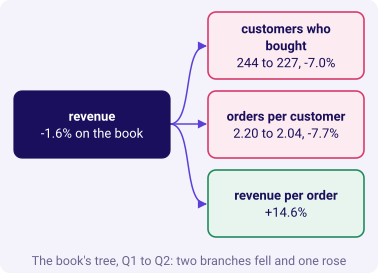

what this chapter established,the evidence
"revenue, orders and revenue per order agree with last week",within half a point each
the customer leaf does not,"flat in the extract, 244 to 227 in the book"
the extract held only two-quarter customers,"69 of 69, against 170 of 301 in the book"


In [14]:
kit.driver_tree({"label": "revenue", "note": f"{pct(book['Q1']['revenue'], book['Q2']['revenue']):+.1f}% on the book",
                 "kind": "lit", "children": [
    {"label": "customers who bought", "note": f"244 to 227, {honest['customers']:+.1f}%", "kind": "bad"},
    {"label": "orders per customer", "note": f"2.20 to 2.04, {honest['orders per customer']:+.1f}%", "kind": "bad"},
    {"label": "revenue per order", "note": f"{pct(*branch(book, 'revenue per order')):+.1f}%", "kind": "good"}]},
    title="The book's tree, Q1 to Q2: two branches fell and one rose")
kit.table(["what this chapter established", "the evidence"],
          [("revenue, orders and revenue per order agree with last week", "within half a point each"),
           ("the customer leaf does not", "flat in the extract, 244 to 227 in the book"),
           ("the extract held only two-quarter customers", "69 of 69, against 170 of 301 in the book")],
          caption="The comparison, in three lines")

**What happened.** The answer is b. The line names both branches the book shows falling and
says why the extract could not show the first: its 69 customers all bought in both quarters.
Option a repeats the one leaf that agrees, c goes further than one chapter's evidence, and d
leaves Meera deciding on a story the book does not tell. Chapters 3 and 4 find which segment
carries each branch.

In [15]:
kit.check("the sheet's customer line comes from the book, 244 to 227",
          (book["Q1"]["customers"], book["Q2"]["customers"]) == (244, 227), f"{honest['customers']:+.1f}%")
kit.check("the sheet's frequency line comes from the book, not the extract",
          round(honest["orders per customer"], 1) == -7.7 and round(hurried["orders per customer"], 1) == -14.0)

> **Kavya's review.** A matching total is one leaf matching. Set every leaf beside its twin
> before you say two sources agree, and when they disagree, say which one is the book and put
> the difference in writing, in the line under the number.

### In the interview: what do you do when two sources disagree?

**[D] Two analysts report different customer counts for the same quarter; how do you settle
it?** Put the two definitions side by side before the two numbers. Most disagreements are
definitions: rows against people, customers who bought against customers on the book, one
window against another. Recompute both from the source of record with each definition written
in the query, agree which definition answers the question in front of you, and store that
query so the next count comes from the same place. Here the extract and the warehouse agreed on
revenue and disagreed on customers because the extract held only customers who bought in both
quarters.

**[F] Your total matches last week's; is your analysis the same as last week's?** Only on that
leaf. A total is a product of branches, and different branches can multiply to the same
product: here 1.000 times 0.860 times 1.144 and 0.930 times 0.923 times 1.146 both give 0.984.
Check every leaf as a change before saying two sources tell the same story.

### Depth: what can an extract that holds only two-quarter customers never show?

A customer who stopped buying after Q1, or started in Q2, has orders in one quarter only. An
extract drawn from customers present in both quarters leaves every such customer out, so its
customer count is flat by the way it was drawn, and every branch divided by customers carries
the error forward. On the book those customers are 131 of 301. Whenever a file arrives from
somewhere else, count how many of its customers appear in both windows, and compare it with the
book before a branch built on customers goes anywhere.

## What did this chapter answer?

1. **How can two sources of different sizes be compared fairly?** Every leaf as a change from
   Q1 to Q2, since the sources differ five times in size and share no order or customer id.
2. **Does last week's file still give last week's numbers?** Yes: 186 orders, Rs 1,90,00,000
   and Rs 1,87,00,000, and 69 customers in each quarter, all 69 of whom bought in both.
3. **Which leaves agree?** Revenue (down 1.6 percent in both), orders (down 14.0 and 14.1) and
   revenue per order (up 14.4 and 14.6).
4. **Did the customer leaf agree?** No: the extract's customers held flat, and the book's fell
   7.0 percent, from 244 to 227, with orders per customer down 7.7 percent where the extract
   said 14.0.
5. **Where did the 17 fewer customers come from?** 74 bought in Q1 and not in Q2, and 57 bought
   in Q2 and not in Q1: 244 less 74 plus 57 is 227.
6. **What goes on Anand's sheet?** The book's leaves, with one line saying that on the whole
   book 7.0 percent fewer customers bought in Q2 as well as each buying 7.7 percent less often.

Chapter 3 splits the book by segment, to find which one carried the fall.

In [16]:
kit.check_summary()